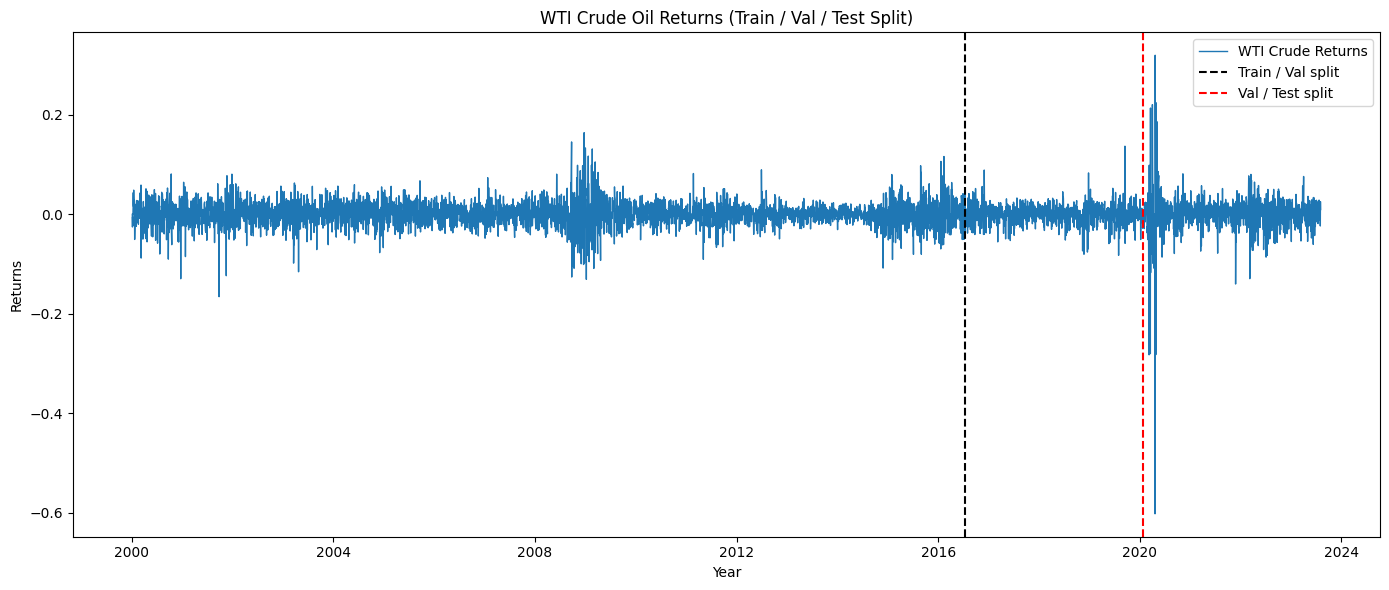

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

train = pd.read_csv("../data/splits/train.csv")
val   = pd.read_csv("../data/splits/val.csv")
test  = pd.read_csv("../data/splits/test.csv")

train["date"] = pd.to_datetime(train["Date"])
val["date"]   = pd.to_datetime(val["Date"])
test["date"]  = pd.to_datetime(test["Date"])

# Ensure numeric
train_y = pd.to_numeric(train["WTI CRUDE"], errors="coerce")
val_y   = pd.to_numeric(val["WTI CRUDE"], errors="coerce")
test_y  = pd.to_numeric(test["WTI CRUDE"], errors="coerce")

# Combine series + dates
full_series = pd.concat([train_y, val_y, test_y]).dropna()
full_dates  = pd.concat([train["date"], val["date"], test["date"]]).iloc[:len(full_series)]

# Set datetime index
full_series.index = full_dates

# Split boundaries (by time, not index)
train_end_date = train["date"].iloc[-1]
val_end_date   = val["date"].iloc[-1]

# Plot
plt.figure(figsize=(14,6))
plt.plot(full_series.index, full_series.values, label="WTI Crude Returns", linewidth=1)

# Vertical split lines
plt.axvline(train_end_date, color="black", linestyle="--", label="Train / Val split")
plt.axvline(val_end_date, color="red", linestyle="--", label="Val / Test split")

# Labels for splits
plt.text(train_end_date, plt.ylim()[1]*0.95, "", color="black")
plt.text(val_end_date, plt.ylim()[1]*0.95, "", color="red")

plt.title("WTI Crude Oil Returns (Train / Val / Test Split)")
plt.xlabel("Year")
plt.ylabel("Returns")
plt.legend()
plt.tight_layout()
plt.show()

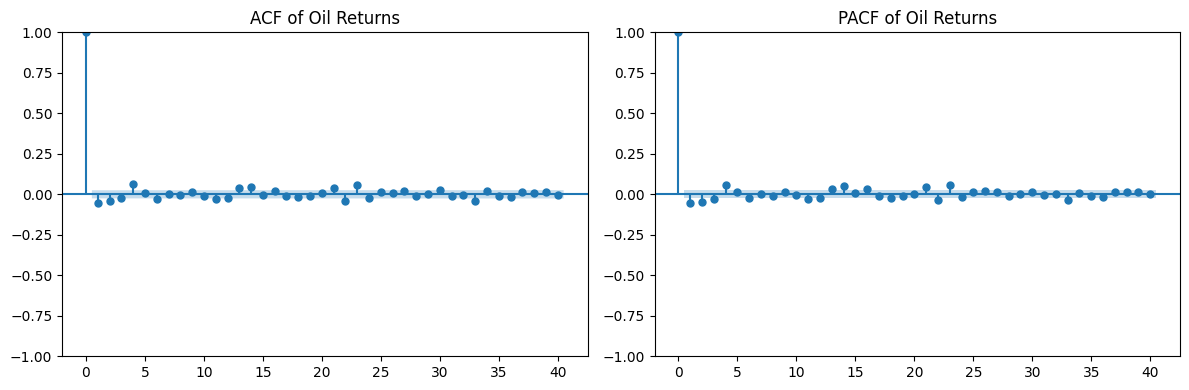

In [10]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# assume your returns series is called oil_returns
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(full_series, lags=40, ax=ax[0])
ax[0].set_title("ACF of Oil Returns")

plot_pacf(full_series, lags=40, ax=ax[1])
ax[1].set_title("PACF of Oil Returns")

plt.tight_layout()
plt.show()

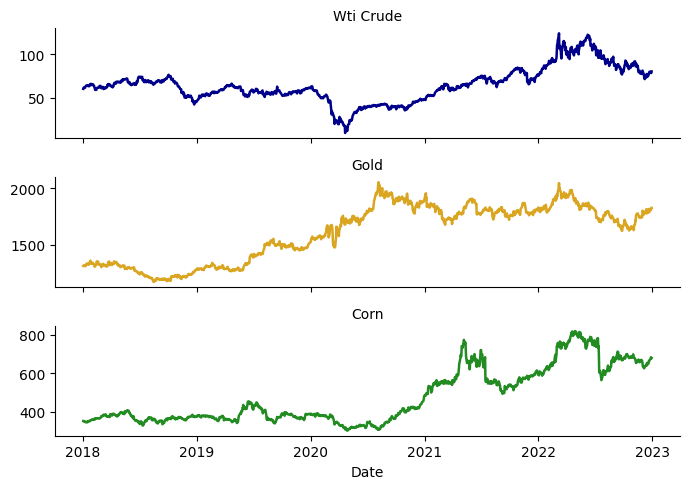

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
prices_df = pd.read_csv("../data/commodity_prices_cleaned.csv")

# -----------------------------
# Parse dates
# -----------------------------
date_col = prices_df.columns[0]
prices_df[date_col] = pd.to_datetime(prices_df[date_col])

# -----------------------------
# Commodities to visualize
# -----------------------------
commodities = [
    "WTI CRUDE",
    "GOLD",
    "CORN"
]

# -----------------------------
# Select time window
# -----------------------------
start_date = "2018-01-01"
end_date = "2023-01-01"

prices_window = prices_df[
    (prices_df[date_col] >= start_date) &
    (prices_df[date_col] <= end_date)
]

# -----------------------------
# Colors
# -----------------------------
colors = {
    "WTI CRUDE": "darkblue",
    "GOLD": "goldenrod",
    "CORN": "forestgreen"
}

# -----------------------------
# Create stacked plots
# -----------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(7, 5),
    sharex=True
)

for ax, commodity in zip(axes, commodities):

    ax.plot(
        prices_window[date_col],
        prices_window[commodity],
        linewidth=1.8,
        color=colors[commodity]
    )

    # Minimal styling
    ax.set_title(
        commodity.title(),
        fontsize=10,
        pad=6
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(False)

# -----------------------------
# Shared x-axis label
# -----------------------------
axes[-1].set_xlabel("Date")

# -----------------------------
# Tight layout
# -----------------------------
plt.tight_layout()

# -----------------------------
# Save figure
# -----------------------------
plt.savefig(
    "stacked_commodity_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

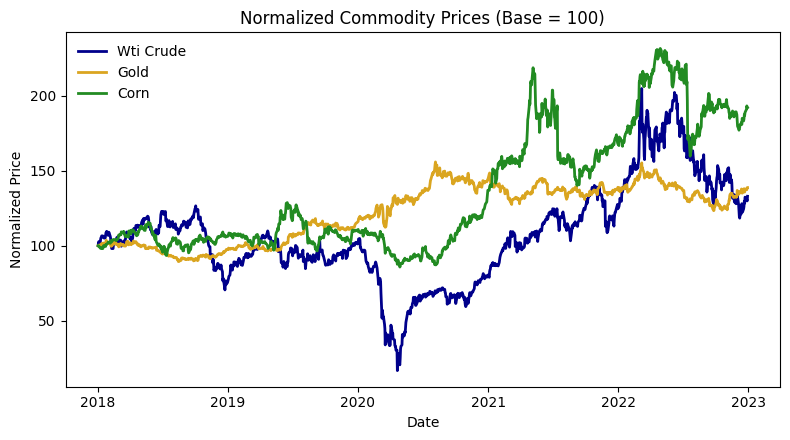

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
prices_df = pd.read_csv("../data/commodity_prices_cleaned.csv")

# -----------------------------
# Parse dates
# -----------------------------
date_col = prices_df.columns[0]
prices_df[date_col] = pd.to_datetime(prices_df[date_col])

# -----------------------------
# Commodities to visualize
# -----------------------------
commodities = [
    "WTI CRUDE",
    "GOLD",
    "CORN"
]

# -----------------------------
# Select time window
# -----------------------------
start_date = "2018-01-01"
end_date = "2023-01-01"

prices_window = prices_df[
    (prices_df[date_col] >= start_date) &
    (prices_df[date_col] <= end_date)
].copy()

# -----------------------------
# Normalize prices
# Base = 100
# -----------------------------
for commodity in commodities:
    prices_window[commodity] = (
        prices_window[commodity]
        / prices_window[commodity].iloc[0]
    ) * 100

# -----------------------------
# Colors
# -----------------------------
colors = {
    "WTI CRUDE": "darkblue",
    "GOLD": "goldenrod",
    "CORN": "forestgreen"
}

# -----------------------------
# Create plot
# -----------------------------
plt.figure(figsize=(8, 4.5))

for commodity in commodities:

    plt.plot(
        prices_window[date_col],
        prices_window[commodity],
        linewidth=2,
        label=commodity.title(),
        color=colors[commodity]
    )

# -----------------------------
# Formatting
# -----------------------------
plt.title("Normalized Commodity Prices (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")

plt.legend(frameon=False)

plt.tight_layout()

# -----------------------------
# Save figure
# -----------------------------
plt.savefig(
    "normalized_commodity_prices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

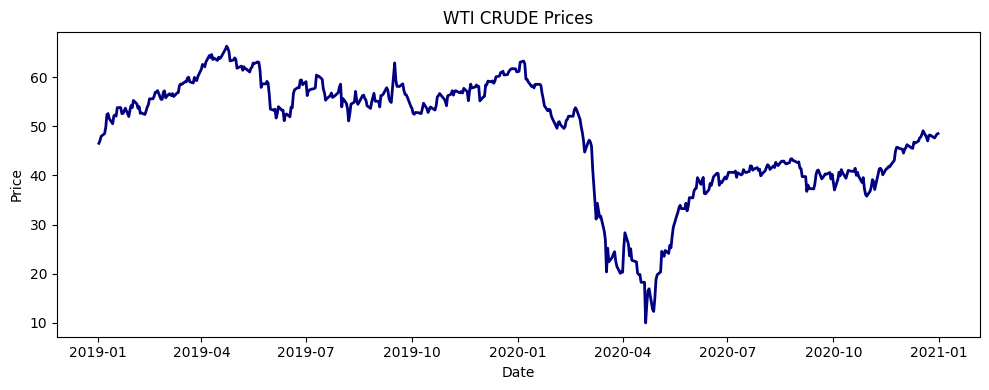

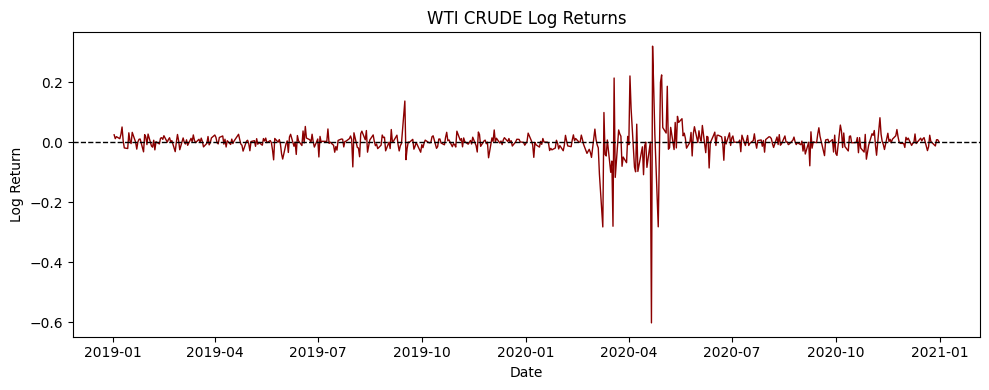

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
returns_df = pd.read_csv("../data/commodity_returns_cleaned.csv")
prices_df = pd.read_csv("../data/commodity_prices_cleaned.csv")

# -----------------------------
# Parse dates
# -----------------------------
date_col = returns_df.columns[0]

returns_df[date_col] = pd.to_datetime(returns_df[date_col])
prices_df[date_col] = pd.to_datetime(prices_df[date_col])

# -----------------------------
# Commodity to visualize
# -----------------------------
commodity = "WTI CRUDE"

# -----------------------------
# Select window
# -----------------------------
start_date = "2019-01-01"
end_date = "2021-01-01"

returns_window = returns_df[
    (returns_df[date_col] >= start_date) &
    (returns_df[date_col] <= end_date)
]

prices_window = prices_df[
    (prices_df[date_col] >= start_date) &
    (prices_df[date_col] <= end_date)
]

# =========================================================
# FIGURE 1: Raw Prices
# =========================================================

plt.figure(figsize=(10, 4))

plt.plot(
    prices_window[date_col],
    prices_window[commodity],
    linewidth=2,
    color="navy"
)

plt.title(f"{commodity} Prices")
plt.xlabel("Date")
plt.ylabel("Price")

plt.tight_layout()

plt.savefig(
    "oil_prices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# FIGURE 2: Log Returns
# =========================================================

plt.figure(figsize=(10, 4))

plt.plot(
    returns_window[date_col],
    returns_window[commodity],
    linewidth=1,
    color="darkred"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
    color="black"
)

plt.title(f"{commodity} Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.tight_layout()

plt.savefig(
    "oil_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
oil_returns = returns_df["WTI CRUDE"]

rolling_vol = oil_returns.rolling(20).std()

threshold = rolling_vol.quantile(0.95)

shock_periods = rolling_vol > threshold

shock_periods

0       False
1       False
2       False
3       False
4       False
        ...  
6086    False
6087    False
6088    False
6089    False
6090    False
Name: WTI CRUDE, Length: 6091, dtype: bool

In [9]:
# Get dates and volatility values where shocks occur
shock_dates = returns_df.loc[shock_periods, date_col]
shock_volatility = rolling_vol[shock_periods]

# Combine into a dataframe
shock_df = pd.DataFrame({
    "Date": shock_dates,
    "Rolling Volatility": shock_volatility
})

print(shock_df)

           Date  Rolling Volatility
448  2001-09-27            0.043947
449  2001-09-28            0.044183
450  2001-10-01            0.044150
451  2001-10-02            0.044251
452  2001-10-03            0.044493
...         ...                 ...
5746 2022-04-07            0.045034
5747 2022-04-08            0.044741
5748 2022-04-11            0.043751
5749 2022-04-12            0.043843
5750 2022-04-13            0.044272

[304 rows x 2 columns]


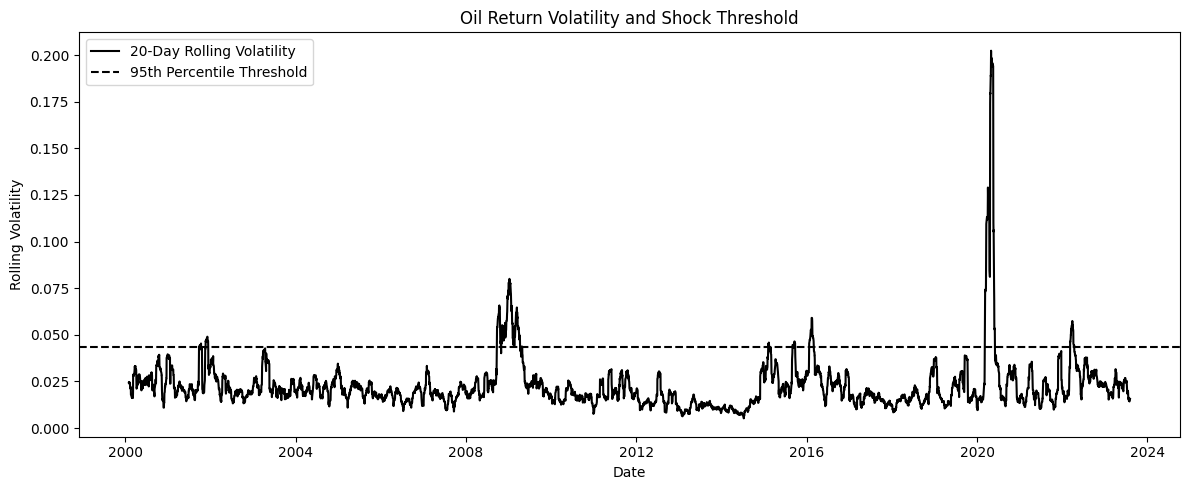

In [13]:
plt.figure(figsize=(12,5))

plt.plot(
    returns_df[date_col],
    rolling_vol,
    label="20-Day Rolling Volatility",
    color = 'black'
)

plt.axhline(
    threshold,
    linestyle="--",
    label="95th Percentile Threshold",
    color = 'black'
)

plt.title("Oil Return Volatility and Shock Threshold")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")

plt.legend()
plt.tight_layout()
plt.show()


Detected Shocks:

           Date   Z-Score
264  2001-01-10  2.401271
271  2001-01-19  2.037380
273  2001-01-23 -3.137472
422  2001-08-22 -2.330567
439  2001-09-14  2.621299
...         ...       ...
5820 2022-07-21 -2.070207
5996 2023-03-27  2.277389
6001 2023-04-03  3.003332
6022 2023-05-02 -2.106822
6051 2023-06-12 -2.382839

[329 rows x 2 columns]


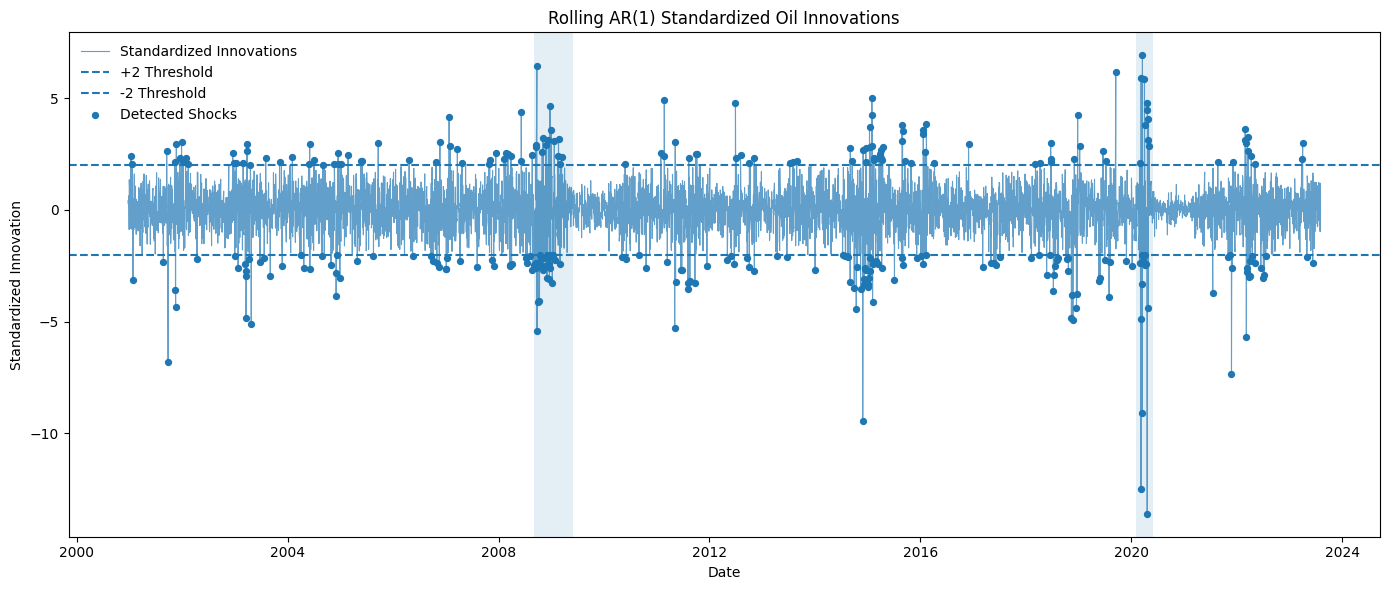

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg

# =========================================================
# Load Data
# =========================================================

returns_df = pd.read_csv("../data/commodity_returns_cleaned.csv")

date_col = returns_df.columns[0]
returns_df[date_col] = pd.to_datetime(returns_df[date_col])

# =========================================================
# Oil Returns
# =========================================================

oil_series = returns_df[["WTI CRUDE", date_col]].dropna()

oil_returns = oil_series["WTI CRUDE"].values
dates = oil_series[date_col].values

# =========================================================
# Parameters
# =========================================================

window_size = 252
ar_lags = 1
threshold = 2

# =========================================================
# Storage
# =========================================================

z_scores = np.full(len(oil_returns), np.nan)

# =========================================================
# Rolling AR(1)
# =========================================================

for t in range(window_size, len(oil_returns)):

    # Rolling estimation window
    window_data = oil_returns[t-window_size:t]

    # Fit AR model
    model = AutoReg(
        window_data,
        lags=ar_lags,
        old_names=False
    )

    fitted_model = model.fit()

    # Forecast next observation
    pred = fitted_model.predict(
        start=len(window_data),
        end=len(window_data)
    )[0]

    # Actual next value
    actual = oil_returns[t]

    # Innovation
    innovation = actual - pred

    # Residual standard deviation
    residual_std = fitted_model.resid.std()

    # Standardized innovation
    z_scores[t] = innovation / residual_std

# =========================================================
# Shock Detection
# =========================================================

shock_mask = np.abs(z_scores) > threshold

shock_df = pd.DataFrame({
    "Date": dates,
    "Z-Score": z_scores
})

print("\nDetected Shocks:\n")
print(shock_df[shock_mask])

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(14,6))

# Main z-score line
plt.plot(
    dates,
    z_scores,
    linewidth=0.8,
    alpha=0.7,
    label="Standardized Innovations"
)

# Threshold lines
plt.axhline(
    threshold,
    linestyle="--",
    linewidth=1.5,
    label="+2 Threshold"
)

plt.axhline(
    -threshold,
    linestyle="--",
    linewidth=1.5,
    label="-2 Threshold"
)

# Highlight ONLY shocks
plt.scatter(
    dates[shock_mask],
    z_scores[shock_mask],
    s=18,
    zorder=3,
    label="Detected Shocks"
)

# Optional: shade crisis periods
plt.axvspan(
    pd.Timestamp("2008-09-01"),
    pd.Timestamp("2009-06-01"),
    alpha=0.12
)

plt.axvspan(
    pd.Timestamp("2020-02-01"),
    pd.Timestamp("2020-06-01"),
    alpha=0.12
)

plt.title("Rolling AR(1) Standardized Oil Innovations")
plt.xlabel("Date")
plt.ylabel("Standardized Innovation")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

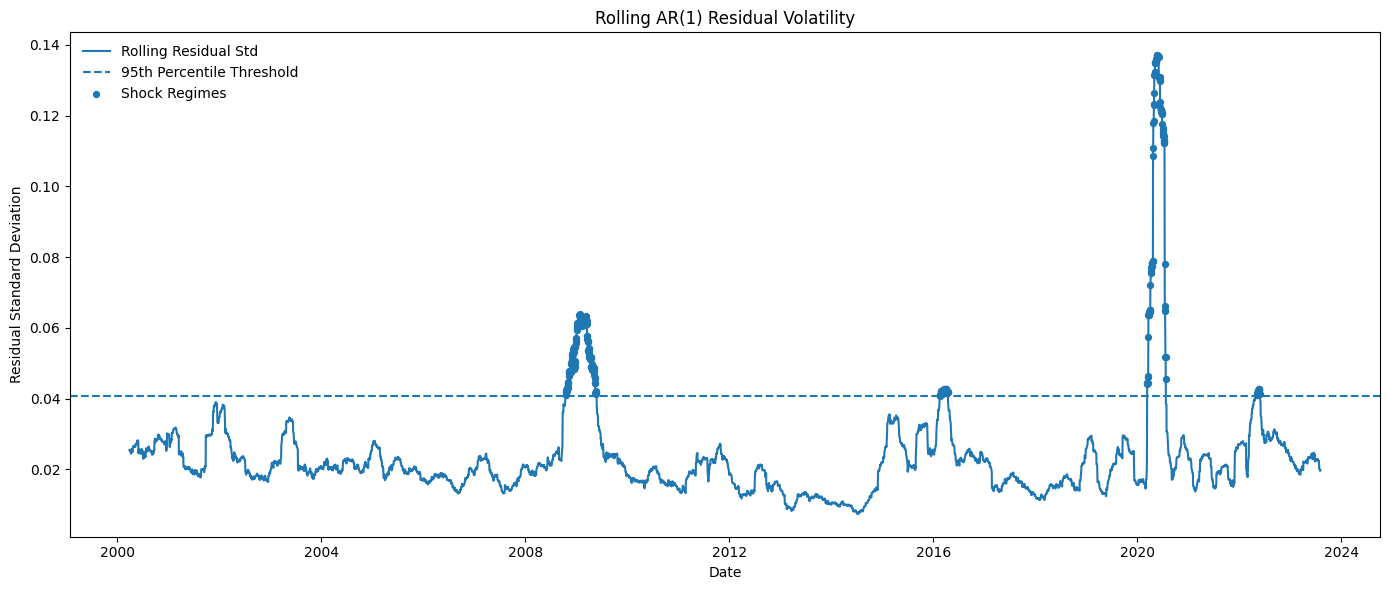

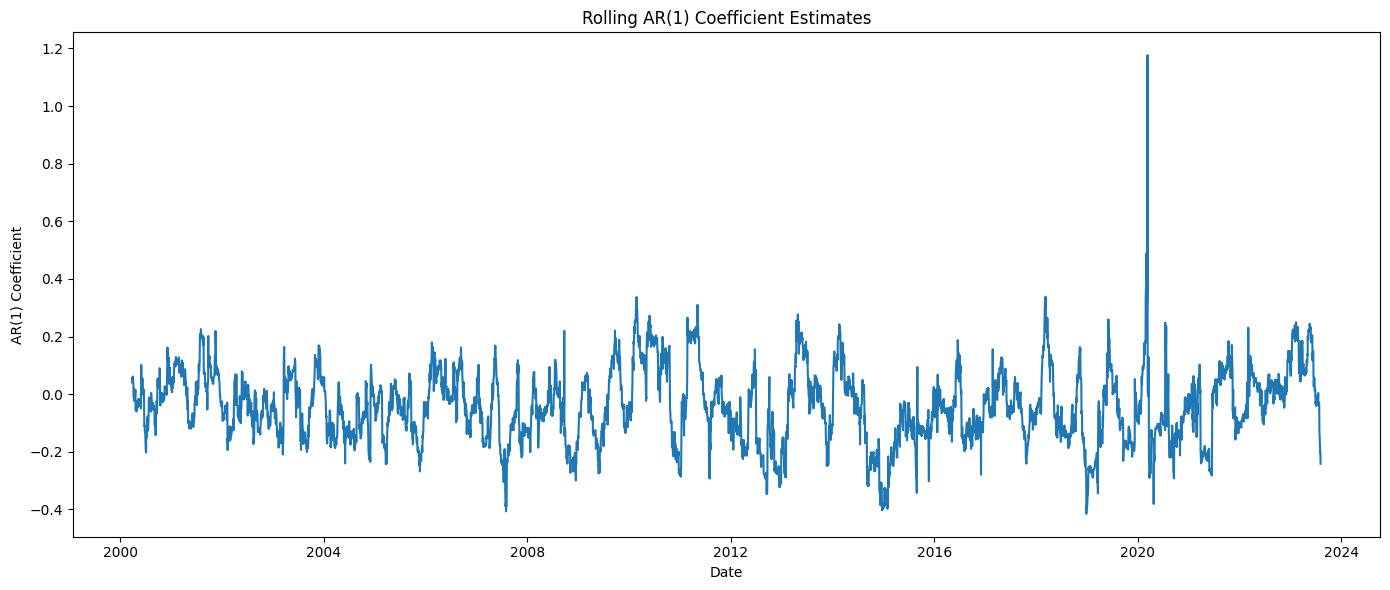

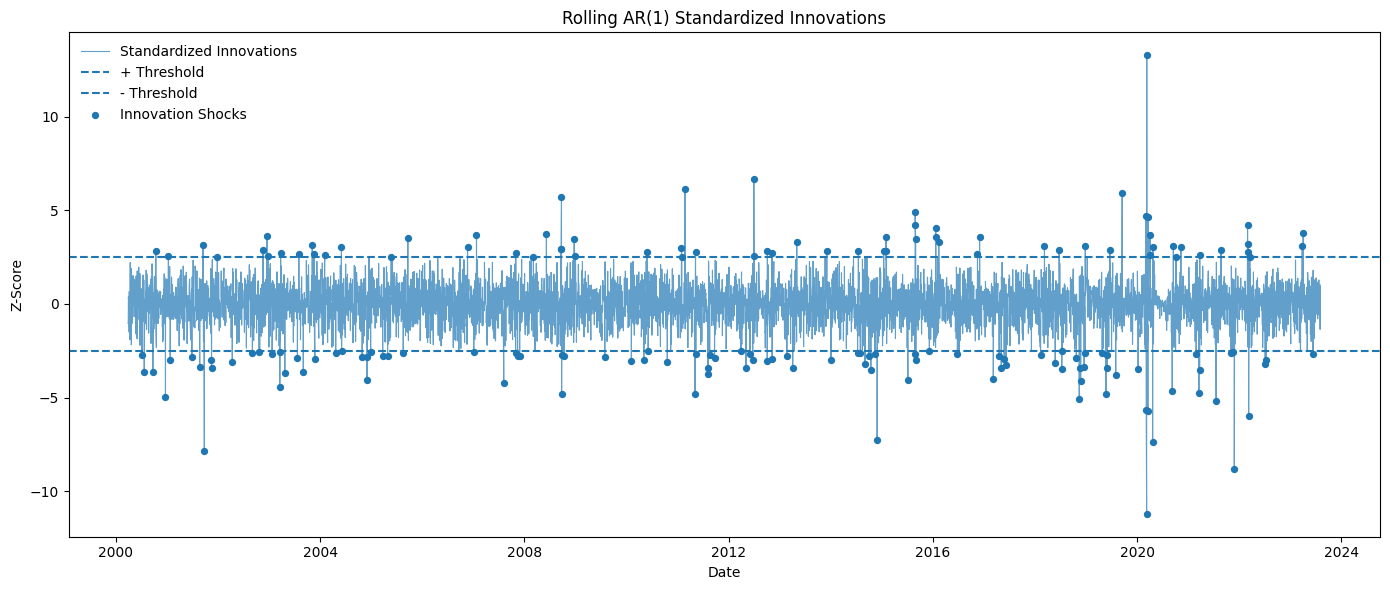

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg

# =========================================================
# Load Data
# =========================================================

returns_df = pd.read_csv("../data/commodity_returns_cleaned.csv")

date_col = returns_df.columns[0]
returns_df[date_col] = pd.to_datetime(returns_df[date_col])

# =========================================================
# Select Oil Returns
# =========================================================

oil_df = returns_df[[date_col, "WTI CRUDE"]].dropna()

dates = oil_df[date_col].values
oil_returns = oil_df["WTI CRUDE"].values

# =========================================================
# Rolling AR Parameters
# =========================================================

window_size = 60    # ~1 trading year
ar_lags = 1

# =========================================================
# Storage Arrays
# =========================================================

rolling_phi = np.full(len(oil_returns), np.nan)
rolling_resid_std = np.full(len(oil_returns), np.nan)
rolling_innovations = np.full(len(oil_returns), np.nan)
rolling_zscores = np.full(len(oil_returns), np.nan)

# =========================================================
# Rolling AR Estimation
# =========================================================

for t in range(window_size, len(oil_returns)):

    # ---------------------------------------------
    # Local rolling window
    # ---------------------------------------------
    window_data = oil_returns[t-window_size:t]

    # ---------------------------------------------
    # Fit AR(1)
    # ---------------------------------------------
    model = AutoReg(
        window_data,
        lags=ar_lags,
        old_names=False
    )

    fitted = model.fit()

    # ---------------------------------------------
    # Store AR coefficient
    # params[0] = intercept
    # params[1] = AR(1) coefficient
    # ---------------------------------------------
    rolling_phi[t] = fitted.params[1]

    # ---------------------------------------------
    # Rolling residual volatility
    # ---------------------------------------------
    resid_std = fitted.resid.std()

    rolling_resid_std[t] = resid_std

    # ---------------------------------------------
    # Forecast next value
    # ---------------------------------------------
    pred = fitted.predict(
        start=len(window_data),
        end=len(window_data)
    )[0]

    actual = oil_returns[t]

    # ---------------------------------------------
    # Innovation
    # ---------------------------------------------
    innovation = actual - pred

    rolling_innovations[t] = innovation

    # ---------------------------------------------
    # Standardized innovation
    # ---------------------------------------------
    rolling_zscores[t] = innovation / resid_std

# =========================================================
# Define Shock Thresholds
# =========================================================

vol_threshold = np.nanpercentile(
    rolling_resid_std,
    95
)

innovation_threshold = 2.5

# Shock regimes from elevated residual variance
vol_shock_mask = rolling_resid_std > vol_threshold

# Innovation outliers
innovation_shock_mask = (
    np.abs(rolling_zscores)
    > innovation_threshold
)

# =========================================================
# Plot 1 — Rolling Residual Volatility
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    dates,
    rolling_resid_std,
    linewidth=1.5,
    label="Rolling Residual Std"
)

plt.axhline(
    vol_threshold,
    linestyle="--",
    linewidth=1.5,
    label="95th Percentile Threshold"
)

# Highlight volatility shock periods
plt.scatter(
    dates[vol_shock_mask],
    rolling_resid_std[vol_shock_mask],
    s=18,
    zorder=3,
    label="Shock Regimes"
)

plt.title("Rolling AR(1) Residual Volatility")
plt.xlabel("Date")
plt.ylabel("Residual Standard Deviation")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

# =========================================================
# Plot 2 — Rolling AR(1) Coefficient
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    dates,
    rolling_phi,
    linewidth=1.5
)

plt.title("Rolling AR(1) Coefficient Estimates")
plt.xlabel("Date")
plt.ylabel("AR(1) Coefficient")

plt.tight_layout()
plt.show()

# =========================================================
# Plot 3 — Standardized Innovations
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    dates,
    rolling_zscores,
    linewidth=0.8,
    alpha=0.7,
    label="Standardized Innovations"
)

plt.axhline(
    innovation_threshold,
    linestyle="--",
    linewidth=1.5,
    label="+ Threshold"
)

plt.axhline(
    -innovation_threshold,
    linestyle="--",
    linewidth=1.5,
    label="- Threshold"
)

# Highlight innovation outliers
plt.scatter(
    dates[innovation_shock_mask],
    rolling_zscores[innovation_shock_mask],
    s=18,
    zorder=3,
    label="Innovation Shocks"
)

plt.title("Rolling AR(1) Standardized Innovations")
plt.xlabel("Date")
plt.ylabel("Z-Score")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [7]:
# =========================================================
# Create Shock Regime Output DataFrame
# =========================================================

shock_output_df = pd.DataFrame({
    "Date": dates,
    "OilReturn": oil_returns,
    "RollingAR1Coefficient": rolling_phi,
    "RollingResidualStd": rolling_resid_std,
    "ResidualVolatilityThreshold": vol_threshold,
    "ShockRegime": vol_shock_mask.astype(int),
    "Innovation": rolling_innovations,
    "StandardizedInnovation": rolling_zscores,
    "InnovationShock": innovation_shock_mask.astype(int)
})

# =========================================================
# Save CSV
# =========================================================

shock_output_df.to_csv(
    "../outputs/oil_shock_regimes.csv",
    index=False
)

print("\nSaved:")
print("../outputs/oil_shock_regimes.csv")

# =========================================================
# Optional Preview
# =========================================================

print("\nShock Regime Preview:\n")

print(
    shock_output_df[
        shock_output_df["ShockRegime"] == 1
    ].head(20)
)


Saved:
../outputs/oil_shock_regimes.csv

Shock Regime Preview:

           Date  OilReturn  RollingAR1Coefficient  RollingResidualStd  \
2265 2008-10-16  -0.064986              -0.226970            0.040921   
2266 2008-10-17   0.028231              -0.197571            0.041790   
2267 2008-10-20   0.032857              -0.209878            0.041853   
2268 2008-10-21  -0.046308              -0.191121            0.042332   
2269 2008-10-22  -0.060175              -0.197575            0.042118   
2270 2008-10-23   0.016198              -0.177093            0.042764   
2271 2008-10-24  -0.055928              -0.183397            0.042771   
2272 2008-10-27  -0.014603              -0.190388            0.043043   
2273 2008-10-28  -0.007781              -0.187374            0.043048   
2274 2008-10-29   0.073288              -0.187151            0.043045   
2275 2008-10-30  -0.023079              -0.186133            0.044311   
2276 2008-10-31   0.027661              -0.179604          

In [8]:
# =========================================================
# Extract Continuous Shock Regimes
# =========================================================

shock_dates = pd.to_datetime(dates[vol_shock_mask])

shock_regimes = []

if len(shock_dates) > 0:

    start_date = shock_dates[0]
    prev_date = shock_dates[0]

    for current_date in shock_dates[1:]:

        # If gap larger than 7 days,
        # start a new regime
        if (current_date - prev_date).days > 7:

            shock_regimes.append(
                (start_date, prev_date)
            )

            start_date = current_date

        prev_date = current_date

    # Add final regime
    shock_regimes.append(
        (start_date, prev_date)
    )

# =========================================================
# Print Shock Regimes
# =========================================================

print("\nDetected Shock Regimes:\n")

for i, (start, end) in enumerate(shock_regimes):

    print(
        f"Shock Regime {i+1}: "
        f"{start.date()} --> {end.date()}"
    )


Detected Shock Regimes:

Shock Regime 1: 2008-10-16 --> 2009-05-21
Shock Regime 2: 2016-02-16 --> 2016-04-13
Shock Regime 3: 2020-03-11 --> 2020-07-22
Shock Regime 4: 2022-05-05 --> 2022-05-25
